## 加载数据

In [3]:
import pandas as pd

# 加载数据
data = pd.read_csv('../../data-hh/my/hh_result/result_all.csv')


# 查看前几行数据，确保加载成功
print(data.head())

         flt_no bd_type    cap aircraft  legs  leg_no  duration  pax  \
0  KgJrsp7Jd78=      窄体  132.0      319     1       1      1.07   25   
1  P9IRwar34h0=      窄体  189.0      321     1       1      1.38  151   
2  mJitm0UDfM4=      窄体  132.0      319     1       1      1.57   38   
3  jXr97M1wpn4=      窄体  132.0      319     1       1      1.58  109   
4  izjfHOxAho4=      窄体  132.0      319     1       1      1.80  124   

              a             b  ...  year  month  day  weekday  hour  minute  \
0  KNqX4/Q5Noc=  HexFWXqbb8I=  ...  2023     10    1        6    12      15   
1  AKQNtuL5r6Q=  Mv6HkAiSLUk=  ...  2023     10    1        6    20      10   
2  n465JzB8Rrw=  N4hmDZN/CJQ=  ...  2023     10    1        6    16      45   
3  N4hmDZN/CJQ=  n465JzB8Rrw=  ...  2023     10    1        6    19      40   
4  5t+HPO9Mu/w=  X5e5r3CS4OA=  ...  2023     10    1        6    13       5   

   second          from            to   unit_price  
0       0  KNqX4/Q5Noc=  HexFWXqbb8I=  

In [6]:
import pandas as pd

# 加载数据
# data = pd.read_csv('../../data-hh/海航系销售结果数据/mid_flt_allmkt_segment_result_sale_tmp_202410221653.csv')
data = pd.read_csv('../../data-hh/my/hh_result/result_all.csv')


data = data.drop_duplicates(subset=['year','month','day', 'from', 'to','flt_no', 'a', 'b', 'c'])
# 查看前几行数据，确保加载和去重成功
print(data.head())

         flt_no bd_type    cap aircraft  legs  leg_no  duration  pax  \
0  KgJrsp7Jd78=      窄体  132.0      319     1       1      1.07   25   
1  P9IRwar34h0=      窄体  189.0      321     1       1      1.38  151   
2  mJitm0UDfM4=      窄体  132.0      319     1       1      1.57   38   
3  jXr97M1wpn4=      窄体  132.0      319     1       1      1.58  109   
4  izjfHOxAho4=      窄体  132.0      319     1       1      1.80  124   

              a             b  ...  year  month  day  weekday  hour  minute  \
0  KNqX4/Q5Noc=  HexFWXqbb8I=  ...  2023     10    1        6    12      15   
1  AKQNtuL5r6Q=  Mv6HkAiSLUk=  ...  2023     10    1        6    20      10   
2  n465JzB8Rrw=  N4hmDZN/CJQ=  ...  2023     10    1        6    16      45   
3  N4hmDZN/CJQ=  n465JzB8Rrw=  ...  2023     10    1        6    19      40   
4  5t+HPO9Mu/w=  X5e5r3CS4OA=  ...  2023     10    1        6    13       5   

   second          from            to   unit_price  
0       0  KNqX4/Q5Noc=  HexFWXqbb8I=  

## 词频统计

In [7]:
import pandas as pd

# 合并 a, b, c 列的数据
combined_data = pd.concat([data['a'], data['b'], data['c']])

# 对合并后的数据进行词频统计
word_frequency = combined_data.value_counts()

# 打印词频统计结果
print("Combined word frequency for columns 'a', 'b', 'c':")
print(word_frequency)


Combined word frequency for columns 'a', 'b', 'c':
vbo2dwBOeps=    517813
/M8gHzjxpNU=    503011
gK3uAaRHrOs=    489006
So/c8CkA/Xs=    480645
KETr2NAmAHE=    431036
                 ...  
DwCmftDLjPw=       106
MgrS1LT2KO4=       103
Eed3EdkMDqg=        62
wbf1sxPhwNM=        60
6OOHgyiXqY0=         1
Name: count, Length: 254, dtype: int64


## word2vec图嵌入

In [8]:
import pandas as pd
from gensim.models import Word2Vec

In [9]:
import pandas as pd
from gensim.models import Word2Vec
import json

# 1. 加载数据
# df = pd.read_csv('../../data-hh/my/202410221653-processed.csv')
df = pd.read_csv('../../data-hh/my/hh_result/result_all.csv')


In [10]:
# 2. 构建训练语料（根据是否存在 c 字段值）
walks = []
for _, row in df.iterrows():
    if pd.notna(row['c']):  # 如果 'c' 不为 NaN，构建 [a, b, c]
        walks.append([row['a'], row['b'], row['c']])
    else:  # 如果 'c' 为 NaN，只构建 [a, b]
        walks.append([row['a'], row['b']])

In [11]:
# 3. 训练 Word2Vec 模型
kwargs = {
    "sentences": walks,
    "min_count": 0,
    "vector_size": 64,
    "sg": 1,
    "hs": 0,
    "workers": 3,
    "window": 5,
    "epochs": 3
}
model = Word2Vec(**kwargs)

In [12]:
# 4. 提取所有唯一城市节点
unique_cities = set(df['a']).union(set(df['b']), set(df['c']))

# 5. 获取嵌入
embeddings = {}
invalid_word = []
for city in unique_cities:
    if city in model.wv:
        embeddings[city] = model.wv[city]
    else:
        invalid_word.append(city)

In [13]:
# 6. 打印统计信息
print(f"无效节点数量: {len(invalid_word)}")
print(f"有效嵌入数量: {len(embeddings)}")

# # 7. 可选：保存嵌入为文件
# with open("city_embeddings.json", "w") as f:
#     json.dump(embeddings, f)


无效节点数量: 1
有效嵌入数量: 254


## 使用 PCA 进行降维和可视化

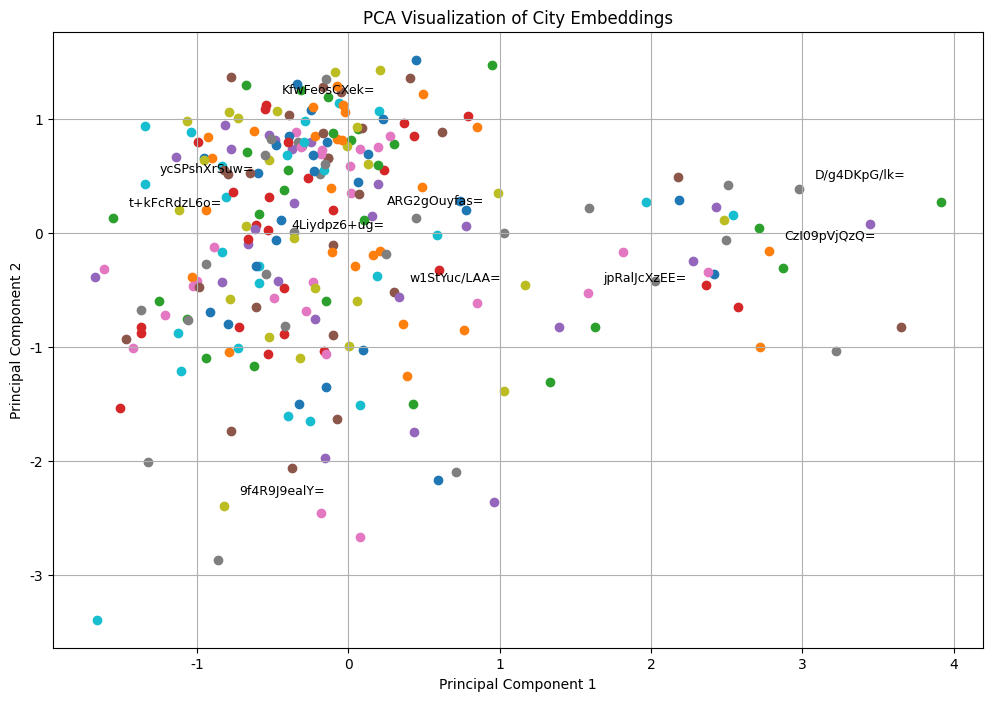

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
# 1. 提取城市及其对应的向量
cities = list(embeddings.keys())
vectors = list(embeddings.values())

# 2. 使用 PCA 降维到 2D
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(vectors)

# 3. 绘制散点图
plt.figure(figsize=(12, 8))
for i, city in enumerate(cities):
    plt.scatter(reduced_vectors[i, 0], reduced_vectors[i, 1], marker='o', label=city if i < 10 else "")  # 只标注前10个城市
    if i < 10:  # 避免标注过多影响图形美观
        plt.text(reduced_vectors[i, 0] + 0.1, reduced_vectors[i, 1] + 0.1, city, fontsize=9)

plt.title("PCA Visualization of City Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()


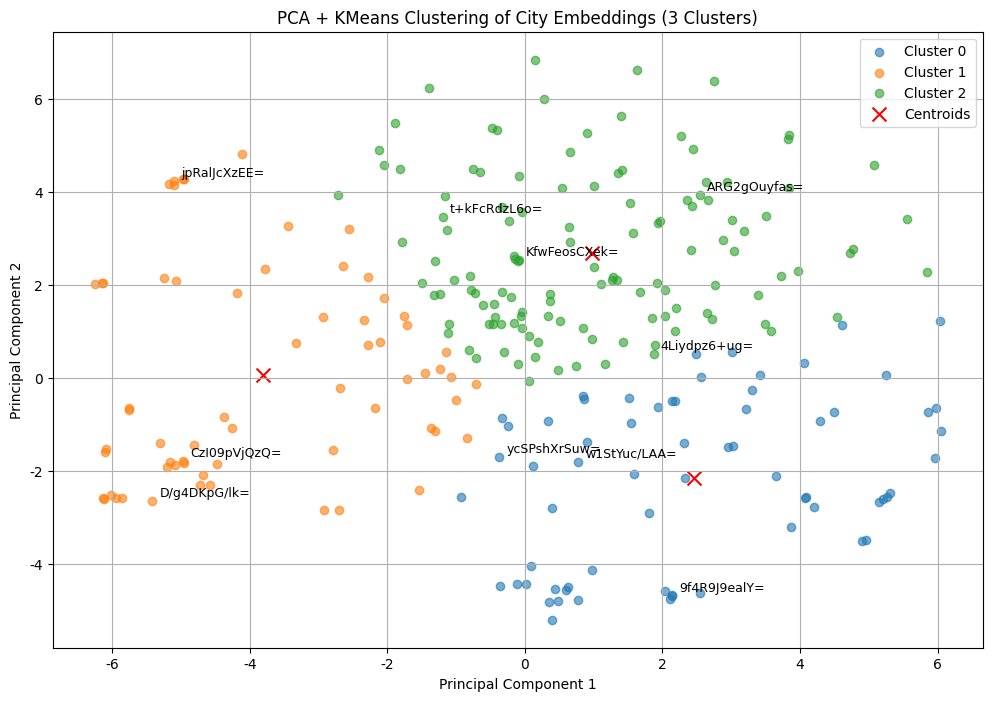

In [17]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
# ====================
# 3. 使用 KMeans 进行聚类（3 个簇）
# ====================
num_clusters = 3  # 将簇数设置为 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
city_clusters = kmeans.fit_predict(reduced_vectors)

# ====================
# 4. 绘制聚类结果
# ====================
plt.figure(figsize=(12, 8))

# 绘制每个簇的城市
for cluster_id in range(num_clusters):
    cluster_points = reduced_vectors[city_clusters == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster_id}', alpha=0.6)

# 绘制城市名称（仅显示前10个城市）
for i, city in enumerate(cities):
    if i < 10:
        plt.text(reduced_vectors[i, 0] + 0.1, reduced_vectors[i, 1] + 0.1, city, fontsize=9)

# 绘制簇中心点
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=100, label='Centroids')

plt.title("PCA + KMeans Clustering of City Embeddings (3 Clusters)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

## 使用 t-SNE 进行降维和可视化

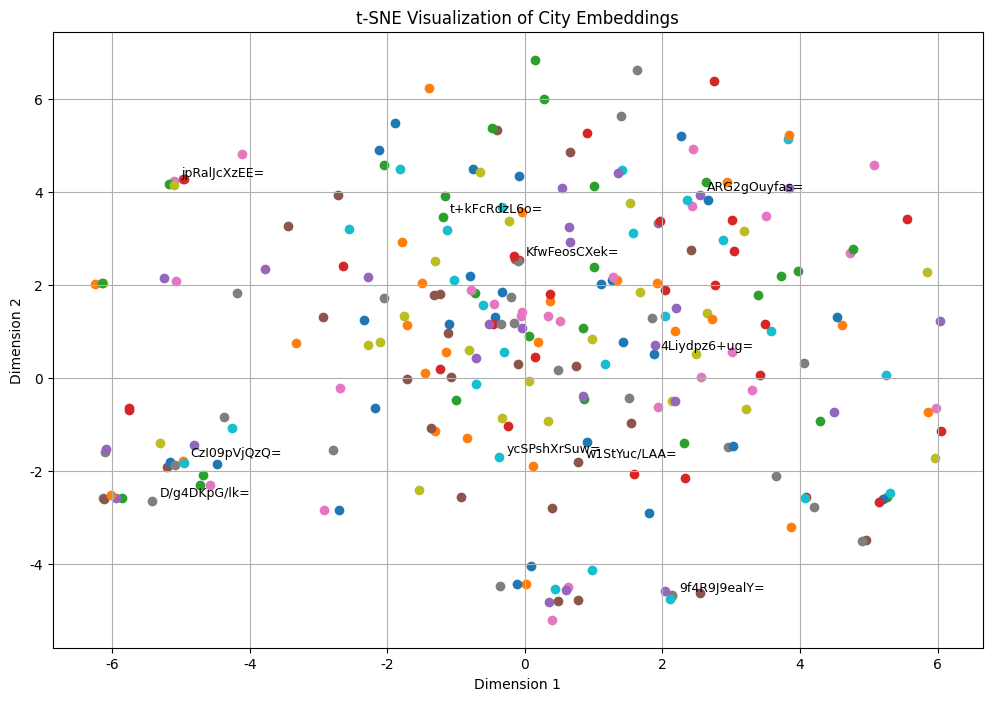

In [16]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. 提取城市及其对应的向量
cities = list(embeddings.keys())
vectors = list(embeddings.values())

# 转换为 NumPy 数组
vectors = np.array(vectors)

# 2. 使用 t-SNE 降维到 2D
tsne = TSNE(n_components=2, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

# 3. 绘制散点图
plt.figure(figsize=(12, 8))
for i, city in enumerate(cities):
    plt.scatter(reduced_vectors[i, 0], reduced_vectors[i, 1], marker='o', label=city if i < 10 else "")  # 标注前10个城市
    if i < 10:  # 避免标注过多影响图形美观
        plt.text(reduced_vectors[i, 0] + 0.1, reduced_vectors[i, 1] + 0.1, city, fontsize=9)

plt.title("t-SNE Visualization of City Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()
